# Cinética de Procesos (Sesión 04)

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, quad, trapezoid
import src.ratelaws as rate

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño


2025

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

# 3 Reacciones en serie

## 3.1 Ejemplo

### 3.1.1 Planteamiento

**Reacciones en serie:**

    Fogler, Ex.8.3, Ex. 8.4


Se lleva a cabo en un reactor Batch una reacción elemental en fase líquida:


$$\mathrm{A} \xrightarrow[]{k_1} \mathrm{B} \xrightarrow[]{k_2} \mathrm{C}$$

El reactor se calienta rápidamente hasta la temperatura de reacción, la cuál se mantiene hasta el tiempo en que la reacción se inactive.

La concentración inicial de la especie $\mathrm{A}$ es $2$ $M$, y las leyes de velocidad de reacción son:

$$\begin{matrix*}[l]
\mathrm{A} \xrightarrow[]{k_1} \mathrm{B} & \quad & -r_{\mathrm{A}} = r_{\mathrm{B}_1}= k_1 C_{\mathrm{A}}= 0.5 \left[\mathrm{h^{-1}}\right] C_{\mathrm{A}}\\
\mathrm{B} \xrightarrow[]{k_2} \mathrm{C} & \quad & -r_{\mathrm{B}_2} = k_2 C_{\mathrm{B}} = 0.2 \left[\mathrm{h^{-1}}\right] C_{\mathrm{B}}\\
\end{matrix*}$$

In [30]:
# Global problem definition
cA0 = 2.0 # [mol.dm-3]
species = ["A", "B", "C"]
k1, k2 = 0.5, 0.2 # kinetic constants (1st order) [h-1]
n1, n2 = 1.0, 1.0 # orders
Q = 2.0 # volumetric flow, [dm3.s-1]

# reaction rate laws
r_A = lambda cA: -k1*cA**(n1)
r_B = lambda cA, cB: k1*cA**(n1) - k2*cB**(n2)
r_C = lambda cB: k2*cB**(n2)

### 3.1.2 Problemática (1)

**Calcule el tiempo (espacial) al cuál la reacción se debe inactivar, para que la concentración de la especie $\mathrm{B}$ se maximice.**

**¿Cuáles serán la selectividad y el rendimiento al momento de inactivar la reacción?**

##### Reactor Batch / PFR

**Reactor Batch**

**Ecuación de diseño**

$$\tau = -\int_{C_{\mathrm{A_0}}}^{C_{\mathrm{A}}} \frac{dC_{\mathrm{A}}}{-r_{\mathrm{A}}} = N_{\mathrm{A}_0} \int_{0}^{X} \frac{dX}{-r_{\mathrm{A}} V} $$

**Reactor PFR:**


**Ecuación de diseño**:

$$\tau = \frac{V}{\dot{Q}} =  - \int_{C_{\mathrm{A}}^0}^{C_{\mathrm{A}}^{*}} \frac{dC_{\mathrm{A}}}{-r_{\mathrm{A}}} = C_{\mathrm{A}}^0 \int_{0}^{X^{*}} \frac{dX_{\mathrm{A}}}{-r_{\mathrm{A}}}$$

La ecuación de tiempo espacial, $\tau$, para un PFR, es similar a la ecuación de diseño para un reactor Batch.

**Curvas cinéticas y conversión**

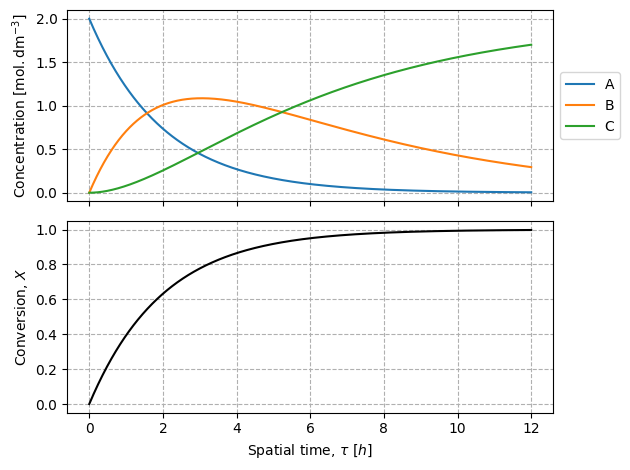

In [31]:
def batch(t, C):
    dC_dt = np.array([
        r_A(C[0]),       
        r_B(C[0], C[1]),
        r_C(C[1])
    ])
    return dC_dt
def batchEnd(t, C):
    return C[0]
batchEnd.terminal = True

eps = 0.0
C0 = (cA0, eps, eps) # concentration [mol.dm-3]
t_span = (0, 12)
dt = 0.01
t_eval = np.arange(t_span[0], t_span[1]+dt, dt)
sol = solve_ivp(
    batch, 
    t_span, 
    y0=C0, 
    events=batchEnd, 
    t_eval=t_eval
)
X = (cA0 - sol.y[0])/cA0 # conversion

fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
for specie, y in zip(species, sol.y):
    ax0.plot(sol.t, y, label=specie)
ax1.plot(sol.t, X, color='k')
ax0.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])
ax0.set_ylabel(r"Concentration [$\mathrm{mol.dm^{-3}}$]")
ax1.set_ylabel(r"Conversion, $X$")
ax1.set_xlabel(r"Spatial time, $\tau$ [$h$]")
ax0.grid(ls='--')
ax1.grid(ls='--')
fig.tight_layout()
plt.show()

**Maximización de la especie $\mathrm{B}$, Selectividad, Rendimiento**

In [32]:
# Maximización de la especie B
indB = np.nanargmax(sol.y[1]) # indice al cuál se maximiza B
Bmax = sol.y[1][indB]

# selectividad
selOvr = sol.y[1][indB] / sol.y[2][indB]     # s = cB/cC

# rendimiento
yieOvr = sol.y[1][indB] / (cA0 - sol.y[0][indB]) # y = cB / (cA0 - cA)

print("Reactor Batch:")
print(f"Bmax={sol.y[1, indB]:.3f} mol/dm3, tau = {sol.t[indB]:.2f} hours")
print(f"X={X[indB]:.2f}, S={selOvr:.2f}, Y={yieOvr:.2f}")
print(f"V(PFR): {sol.t[indB]*Q*3600:.1f} dm3")

Reactor Batch:
Bmax=1.086 mol/dm3, tau = 3.05 hours
X=0.78, S=2.27, Y=0.69
V(PFR): 21960.0 dm3


##### Reactor CSTR

**Reactor CSTR:**

**Ecuación de diseño**:

$$\tau = \frac{V}{\dot{Q}} = \frac{\left(C_{\mathrm{A}}^{0} - C_{\mathrm{A}}^{*}\right)}{-r_{\mathrm{A}}^{*}} = \frac{C_{\mathrm{A}}^0 X^{*}}{-r_{\mathrm{A}}^{*}}$$

**Curvas cinéticas y conversión**

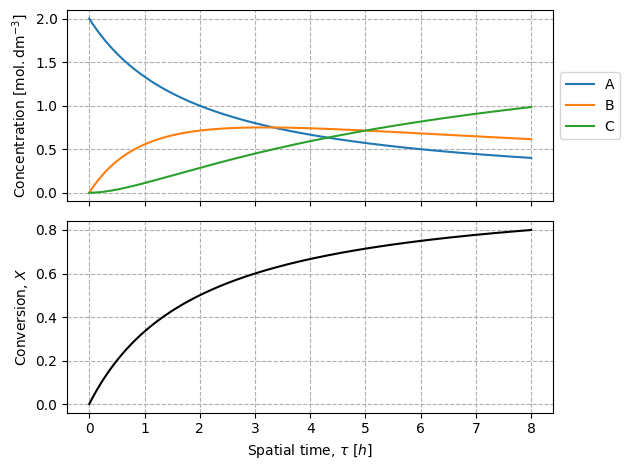

In [33]:
Xmax = 0.8
cA = np.linspace(cA0, (1-Xmax)*cA0, 1000)
xA = 1 - cA/cA0
cstrTau = (cA0 - cA) / (-r_A(cA))
cstrV = Q * cstrTau

# concentraciones
cB = k1*cA*cstrTau / (1+k2*cstrTau) # cstrTau * r_B(cA, cB)
cC = cstrTau * r_C(cB)

fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
for specie, c in zip(species, [cA, cB, cC]):
    ax0.plot(cstrTau, c, label=specie)
ax1.plot(cstrTau, xA, color='k')
ax0.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])
ax0.set_ylabel(r"Concentration [$\mathrm{mol.dm^{-3}}$]")
ax1.set_ylabel(r"Conversion, $X$")
ax1.set_xlabel(r"Spatial time, $\tau$ [$h$]")
ax0.grid(ls='--')
ax1.grid(ls='--')
fig.tight_layout()
plt.show()

**Maximización de la especie $\mathrm{B}$, Selectividad, Rendimiento**

In [34]:
# Maximización de la especie B
indB = np.nanargmax(cB) # indice al cuál se maximiza B
Bmax = cB[indB]

# selectividad
selOvr = cB[indB]/cC[indB]     # s = cB/cC

# rendimiento
yieOvr = cB[indB] / (cA0 - cA[indB]) # y = cB / (cA0 - cA)

print("Reactor CSTR:")
print(f"Bmax={Bmax:.3f} mol/dm3, tau = {cstrTau[indB]:.2f} hours")
print(f"X={xA[indB]:.2f}, S={selOvr:.2f}, Y={yieOvr:.2f}")
print(f"V(CSTR): {cstrTau[indB]*Q*3600:.1f} dm3")

Reactor CSTR:
Bmax=0.750 mol/dm3, tau = 3.16 hours
X=0.61, S=1.58, Y=0.61
V(CSTR): 22772.1 dm3
